In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
data = pd.read_csv(r"C:\Users\anike\Downloads\global_energy_stability_combined_v11.csv")
data.head()

,id,country,state,district,lat,lon,grid_zone,hour_of_day,day_of_week,month,...,storm_type,lightning_strikes,total_power_capacity_mw,renewable_power_mw,fossil_power_mw,electricity_demand_mw,grid_load_percent,outages_last_7_days,outages_last_30_days,outage_in_next_24_hours
0,1,USA,State_E,District_2,-6.221564,73.303210,West,6,Thu,2,...,Heatwave,2,10685.912663,4438.561718,6393.382805,3284.254871,40.960275,1.111801,7.357904,0
1,2,Canada,State_A,District_4,-4.096962,107.221499,South,16,Tue,10,...,Duststorm,0,7538.578055,3508.144615,4153.306123,4854.664324,67.323740,0.394406,5.484861,0
2,3,Japan,State_C,District_6,32.699027,-23.949054,East,0,Thu,6,...,NaN,0,8945.907129,3651.222683,5287.120835,3117.595540,NaN,2.779589,16.927435,0
3,4,USA,State_C,District_10,42.594049,67.991516,West,4,Fri,10,...,NaN,1,7366.793114,3523.932123,3768.261950,10218.857044,NaN,NaN,9.528598,1
4,5,USA,State_D,District_7,-17.746673,-56.177172,East,15,Mon,9,...,Duststorm,4,12109.619637,6395.583774,5923.937790,7401.685866,NaN,1.997359,11.620220,0


The dataset represents global energy grid conditions across different locations and time periods. It includes weather conditions, power generation capacity, electricity demand, and historical outage patterns to predict the risk of power outages in the next 24 hours

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       1000 non-null   int64  
 1   country                  1000 non-null   object 
 2   state                    1000 non-null   object 
 3   district                 1000 non-null   object 
 4   lat                      1000 non-null   float64
 5   lon                      1000 non-null   float64
 6   grid_zone                1000 non-null   object 
 7   hour_of_day              1000 non-null   int64  
 8   day_of_week              1000 non-null   object 
 9   month                    1000 non-null   int64  
 10  season                   1000 non-null   object 
 11  is_holiday               1000 non-null   int64  
 12  temperature_celsius      806 non-null    float64
 13  rainfall_mm              795 non-null    float64
 14  wind_speed_kmh           

The dataset contains 1,000 records and 26 features wich covers location, time, weather conditions, power generation, electricity demand and historical outage patterns. It includes a balanced mix of numerical and categorical variables, making it suitable for supervised machine learning. Several weather, demand, and historical outage columns contain missing values, reflecting real-world data collection challenges. The target variable, which predicts whether a power outage will occur in the next 24 hours, is clearly defined and complete.

In [5]:
data.describe()

,id,lat,lon,hour_of_day,month,is_holiday,temperature_celsius,rainfall_mm,wind_speed_kmh,storm_happened,lightning_strikes,total_power_capacity_mw,renewable_power_mw,fossil_power_mw,electricity_demand_mw,grid_load_percent,outages_last_7_days,outages_last_30_days,outage_in_next_24_hours
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,806.000000,795.000000,818.000000,1000.000000,1000.0000,1000.000000,811.000000,1000.000000,816.000000,812.000000,910.000000,904.000000,1000.00000
mean,500.500000,12.415375,-3.322189,11.394000,6.383000,0.181000,27.524346,9.864425,30.918890,0.146000,2.0780,8092.016436,4037.025229,4060.835420,6973.812269,85.769968,1.594573,8.962826,0.50000
std,288.819436,27.077341,69.320356,6.893496,3.534233,0.385211,8.187302,9.502896,16.858564,0.353283,1.4443,2042.467805,1282.063886,1297.846157,1505.608159,20.819230,1.427842,6.531841,0.50025
min,1.000000,-34.937928,-119.992627,0.000000,1.000000,0.000000,2.915041,-2.401189,-1.083931,0.000000,0.0000,3000.000000,1169.686729,800.493417,2882.231071,37.719558,-0.417063,-1.162287,0.00000
25%,250.750000,-11.018589,-64.036391,6.000000,3.000000,0.000000,21.935924,3.019253,16.626626,0.000000,1.0000,6664.355573,3126.875094,3113.045662,5966.081288,69.866321,0.809267,5.083104,0.00000
50%,500.500000,12.632696,-4.823241,11.000000,6.000000,0.000000,27.732915,7.234754,30.452253,0.000000,2.0000,8033.105488,3910.928394,3983.661252,6978.975231,87.551067,1.121717,7.496898,0.50000
75%,750.250000,35.272507,55.605738,17.000000,9.000000,0.000000,33.153167,13.971083,45.886143,0.000000,3.0000,9480.743917,4859.322238,4916.643427,7919.719670,106.084290,2.182017,11.929662,1.00000
max,1000.000000,59.957982,119.459853,23.000000,12.000000,1.000000,46.263804,82.812166,63.205990,1.000000,8.0000,14571.447427,9123.174508,10908.462204,11219.660939,119.086536,5.446182,26.879255,1.00000


The numbers in the dataset, like average temperature, rainfall, wind speed, and grid load. It helps see what values are normal, what is high or low, and how much things vary. This makes it easier to understand the general patterns in weather conditions and power grid stress before doing deeper analysis.

In [6]:
data.shape

(1000, 26)

The dataset contains 1,000 observations and 26 features, indicating a moderately sized dataset that is sufficient for training and comparing multiple supervised machine learning models while reducing the risk of overfitting.

In [7]:
data.duplicated().sum()

np.int64(0)

There are no duplicate records in the dataset which means observation are unique and there are no repeated entries. 

In [8]:
num_cols = data.select_dtypes(include=['float64','int64']).columns
cat_cols = data.select_dtypes(include=['object']).columns
num_cols, cat_cols

(Index(['id', 'lat', 'lon', 'hour_of_day', 'month', 'is_holiday',
        'temperature_celsius', 'rainfall_mm', 'wind_speed_kmh',
        'storm_happened', 'lightning_strikes', 'total_power_capacity_mw',
        'renewable_power_mw', 'fossil_power_mw', 'electricity_demand_mw',
        'grid_load_percent', 'outages_last_7_days', 'outages_last_30_days',
        'outage_in_next_24_hours'],
       dtype='object'),
 Index(['country', 'state', 'district', 'grid_zone', 'day_of_week', 'season',
        'storm_type'],
       dtype='object'))

It shows that the data has seperated into numrical and categorical features. The numerical columns contain measurable values like temperature, power, demand and past outages which can be directly used for analysis. While the categorical columns describe qualities like location, day, season and storm type that will need to be converted into numbers before applying machine learning models

In [9]:
for col in num_cols:
    data[col] = data[col].fillna(data[col].median())
data[num_cols].isnull().sum()

id                         0
lat                        0
lon                        0
hour_of_day                0
month                      0
is_holiday                 0
temperature_celsius        0
rainfall_mm                0
wind_speed_kmh             0
storm_happened             0
lightning_strikes          0
total_power_capacity_mw    0
renewable_power_mw         0
fossil_power_mw            0
electricity_demand_mw      0
grid_load_percent          0
outages_last_7_days        0
outages_last_30_days       0
outage_in_next_24_hours    0
dtype: int64

The missing values in numerical columns are handled by using median imputation. The median was choosen instead of the mean because it is more robust to outliers and extreme values, ensuring that the original data distribution is not heavily distorted during preprocessing.

In [10]:
for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])
data[cat_cols].isnull().sum()

country        0
state          0
district       0
grid_zone      0
day_of_week    0
season         0
storm_type     0
dtype: int64

I filled all missing values in categorical columns using the mode, which means I replaced missing values with the most common category in each column. Now there are no missing values left in these columns, so the categorical data is clean and complete.

In [11]:
data['outage_in_next_24_hours'].value_counts()

outage_in_next_24_hours
0    500
1    500
Name: count, dtype: int64

The target column shows how many cases had an outage versus no outage in the next 24 hours. This helps in understanding whether outages are rare or common in the dataset which is important because highly imbalanced data can affect prediction performance.

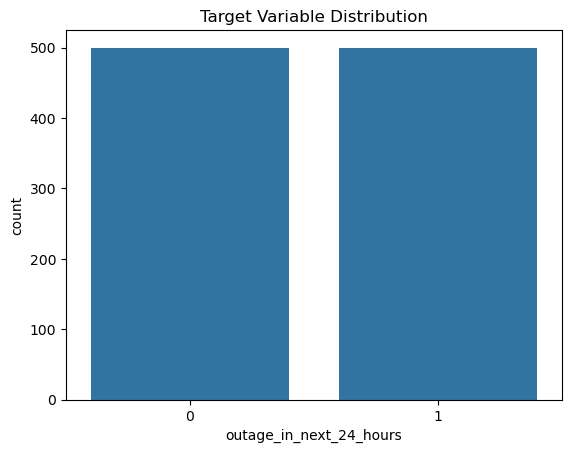

In [12]:
sns.countplot(x='outage_in_next_24_hours', data=data)
plt.title("Target Variable Distribution")
plt.show()

This graph shows that outages (1) and no outages (0) happen almost the same number of times in your dataset. That means the data is balanced and fair.

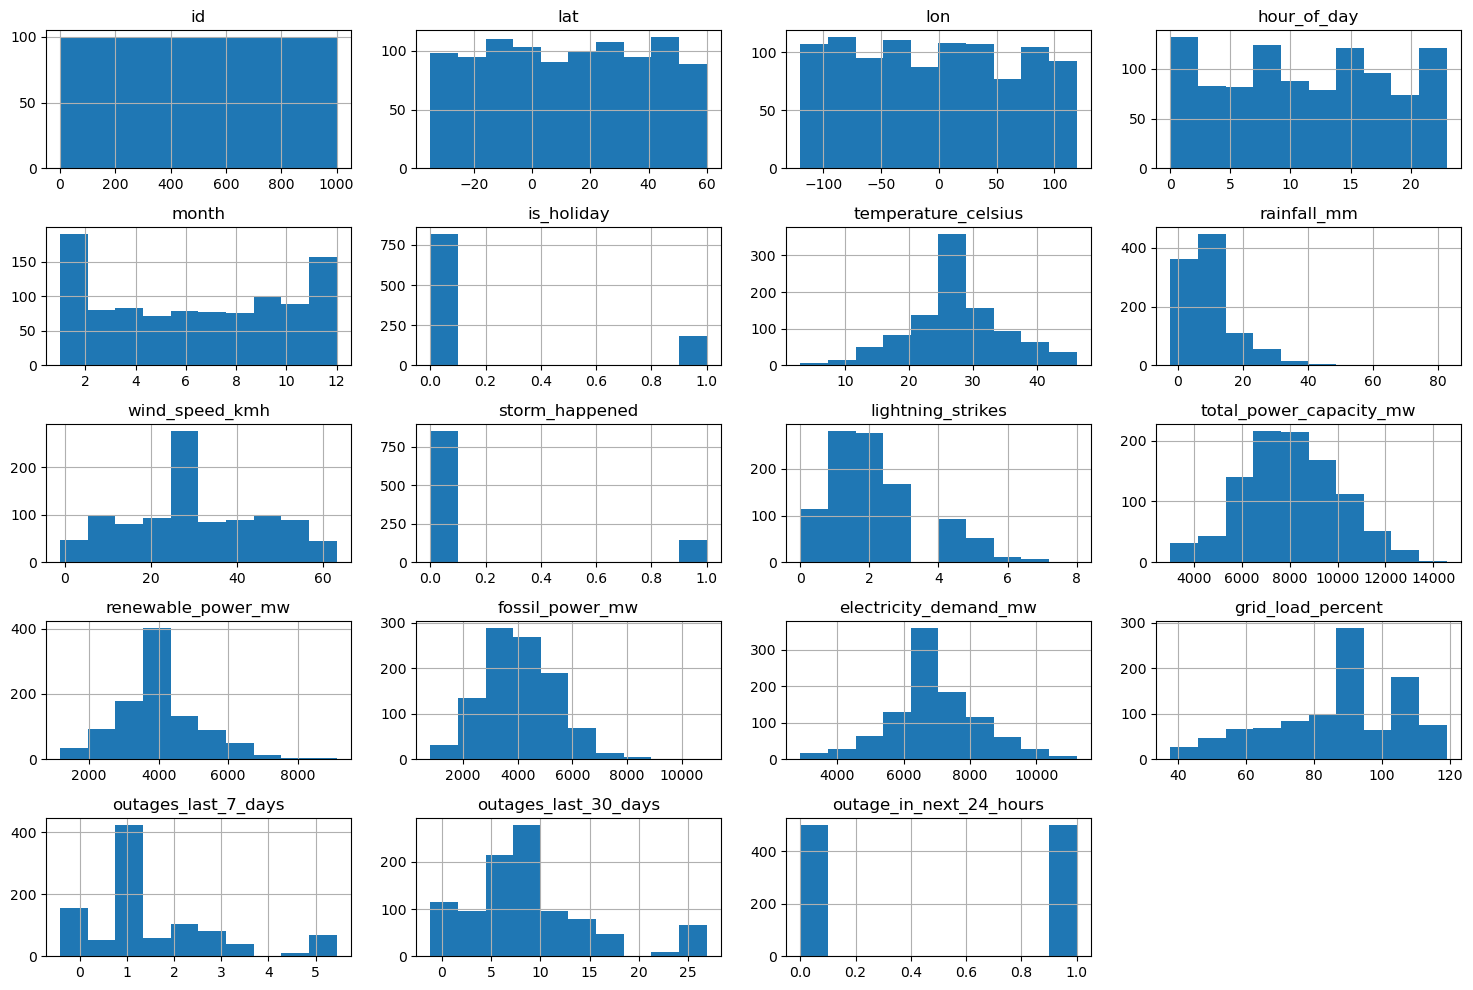

In [13]:
data[num_cols].hist(figsize=(15,10))
plt.tight_layout()
plt.show()

1.Most features like temperature, demand, fossil power, renewable power and total capacity are normally distributed, meaning most values are around the   average and extreme values are few.

2.Rainfall is slightly skewed, which shows most days have low rainfall and only a few days have heavy rain.

3.Lightning strikes mostly have lower values, with very few high cases.

4.is_holiday and storm_happened are mostly 0, meaning holidays and storms are less frequent events.

5.Past outage columns show smaller outage counts are common, while very high counts are rare.

--Overall, the dataset looks realistic and well spread, with no strange or unnatural patterns.

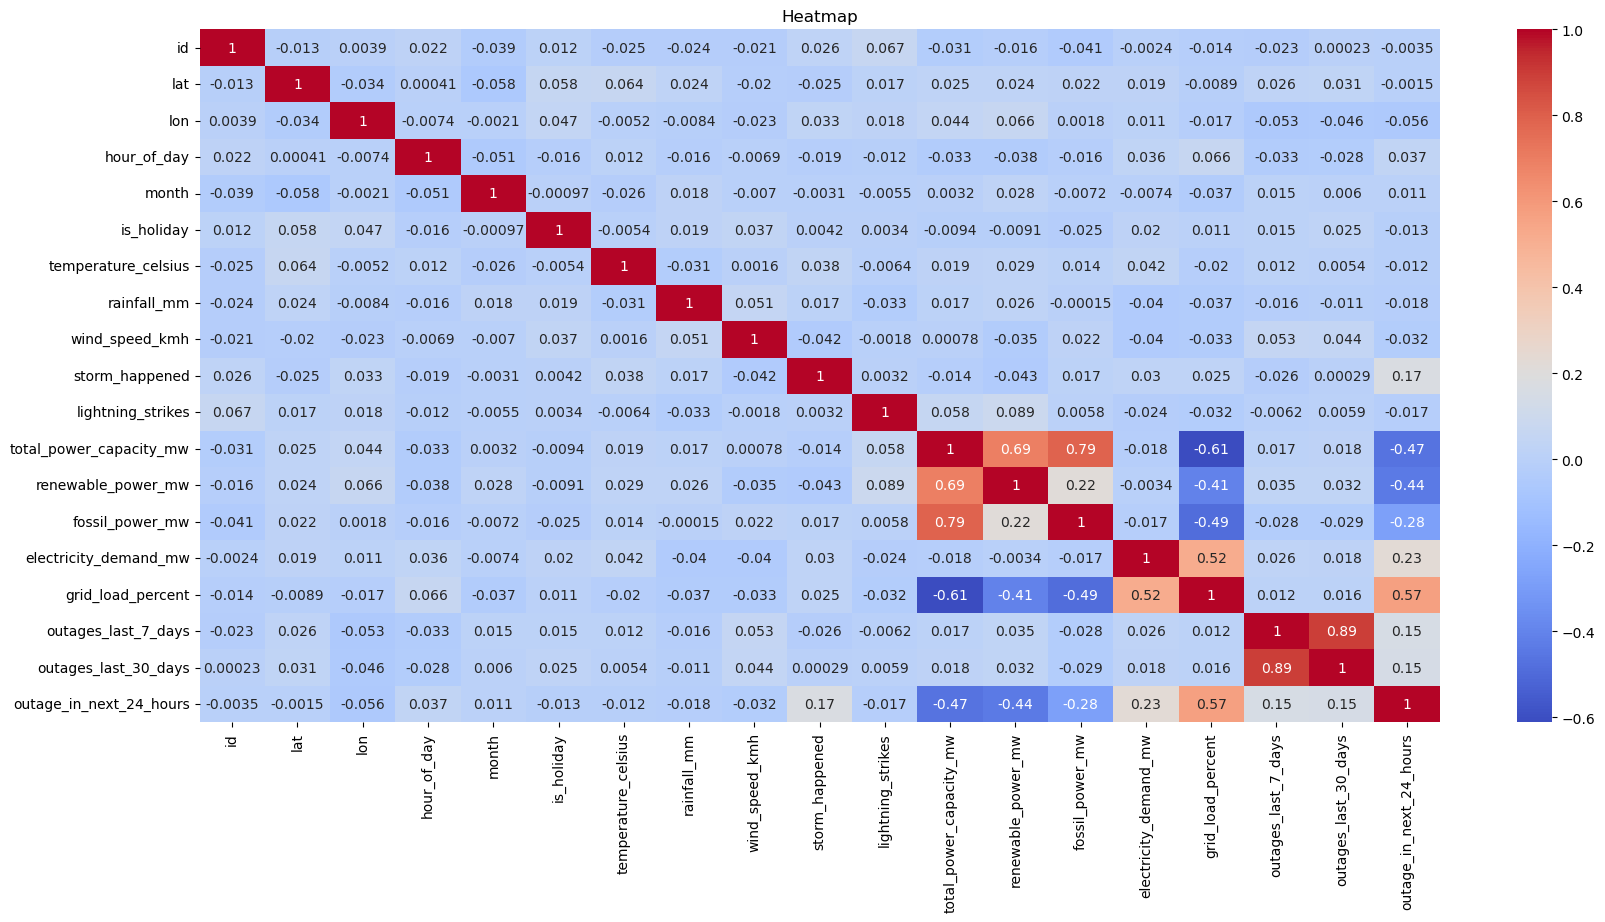

In [14]:
plt.figure(figsize=(20,9))
sns.heatmap(data[num_cols].corr(), cmap='coolwarm',annot=True)
plt.title("Heatmap")
plt.show()

1.outage_in_next_24_hours has a strong positive correlation with grid_load_percent (around 0.57). This means when grid load increases, the chance of    outage also increases. This is an important feature for prediction.

2.electricity_demand_mw also shows moderate positive correlation with outages. Higher demand can increase outage risk.

3.total_power_capacity_mw, renewable_power_mw, and fossil_power_mw show negative correlation with outages. This means higher power supply reduces the   chance of outage.
   
4.outages_last_7_days and outages_last_30_days are highly correlated with each other (very strong positive correlation). This may cause           multicollinearity, so you might keep only one of them.

5.Weather features like temperature, rainfall, and wind speed show very weak correlation with the target. This means they may not strongly influence   outages in your dataset.

--Overall, grid load and demand look like the most important drivers of outages, while higher power capacity reduces risk.

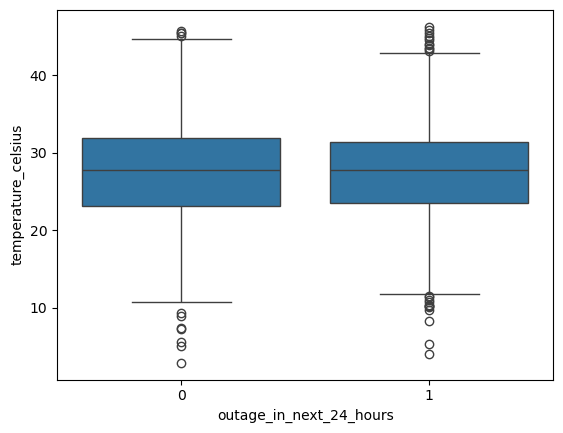

In [15]:
sns.boxplot(x='outage_in_next_24_hours', y='temperature_celsius', data=data)
plt.show()

When we look at this boxplot, the temperature distribution for outage and no outage looks almost the same. The middle line (median) in both boxes is very close, and even the spread of values is quite similar. This tells us that temperature does not change much whether an outage happens or not.

There are some extreme temperature values on both sides, but they appear in both outage and non-outage cases, so they are not clearly linked to outages. Overall, this suggests that temperature alone is not a strong factor in predicting whether an outage will occur in the next 24 hours.

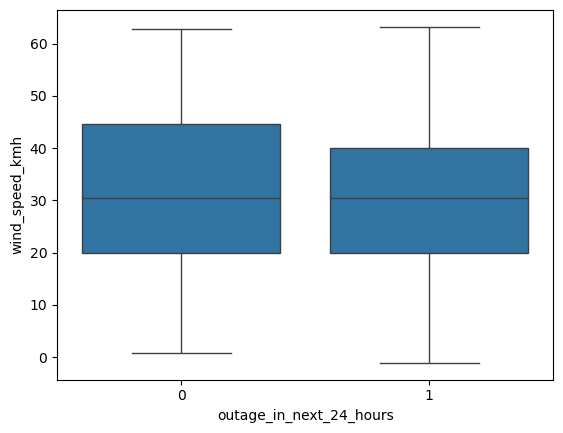

In [16]:
sns.boxplot(x='outage_in_next_24_hours', y='wind_speed_kmh', data=data)
plt.show()

The wind speed distribution for both outage and no outage looks very similar. The median wind speed is almost the same in both cases, and even the spread of values overlaps heavily. This means normal wind conditions are present whether an outage happens or not.

There are some higher wind speeds in both categories, but they are not clearly higher only when outages happen. So from this graph, wind speed alone does not seem to strongly influence whether there will be an outage in the next 24 hours. It might have a small effect, but by itself it doesn’t look like a strong predictor.

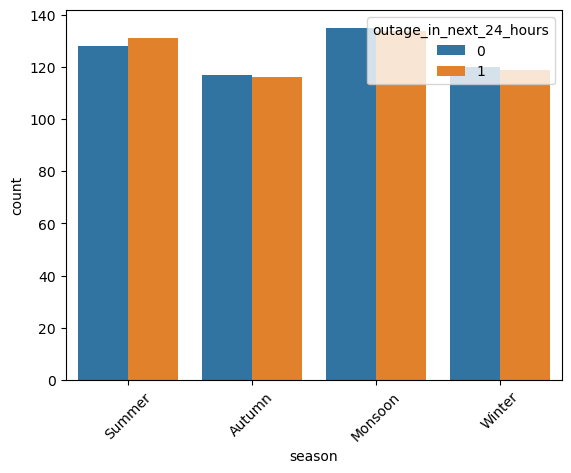

In [17]:
sns.countplot(x='season', hue='outage_in_next_24_hours', data=data)
plt.xticks(rotation=45)
plt.show()

The number of outages and no outages in each season looks almost equal. In Summer, Autumn, Monsoon, and Winter, the bars for 0 and 1 are very close to each other.
This means outages are happening in every season almost equally. There isn’t one specific season where outages are clearly much higher. Even during Monsoon, which we might expect to have more outages because of heavy rain, the difference is not very big.season alone does not look like a strong factor for predicting outages. It may have some effect when combined with other features

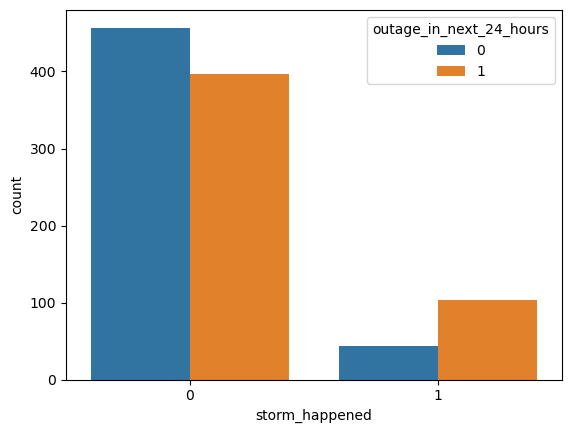

In [18]:
sns.countplot(x='storm_happened', hue='outage_in_next_24_hours', data=data)
plt.show()

When no storm happened (0), outages and no outages are somewhat close, though slightly more “no outage” cases. But when a storm happened (1), the number of outages is clearly higher than no outages.

This means storms have a noticeable impact. When there is a storm, the chances of an outage increase compared to normal days. It’s not perfectly extreme, but the difference is visible.

So unlike temperature or wind speed alone, storm presence looks like a meaningful factor in predicting whether an outage will happen in the next 24 hours.

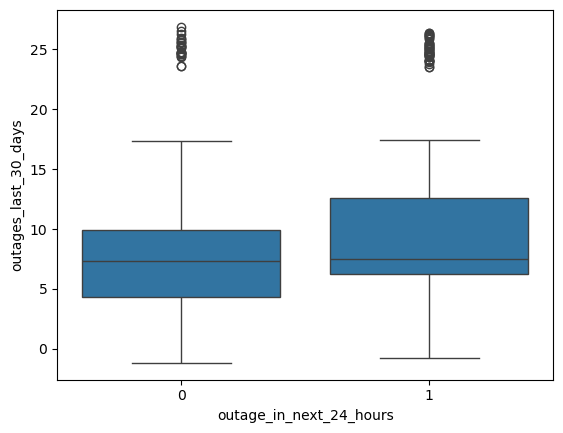

In [19]:
sns.boxplot(x='outage_in_next_24_hours', y='outages_last_30_days', data=data)
plt.show()

When an outage happens in the next 24 hours (1), the number of outages in the last 30 days is generally higher. The median is slightly higher and the whole box is shifted upward compared to the “no outage” case.
This means if a region has experienced more outages recently, it is more likely to face another outage soon. In simple terms, areas with a bad recent history of outages tend to continue having problems.

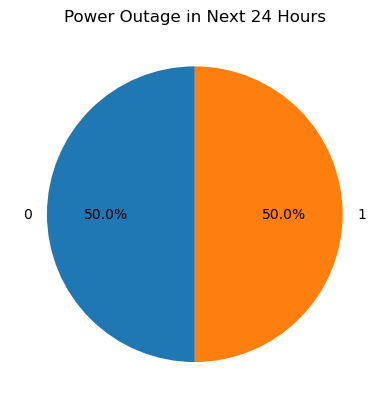

In [20]:
data['outage_in_next_24_hours'].value_counts().plot(kind='pie',autopct='%1.1f%%',startangle=90)
plt.ylabel('')
plt.title('Power Outage in Next 24 Hours')
plt.show()

This pie chart clearly shows that the dataset is perfectly balanced. Exactly 50% of the cases are outages and 50% are no outages in the next 24 hours.

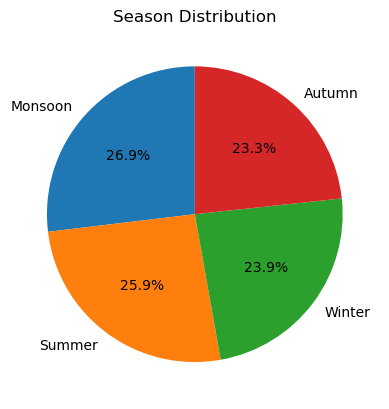

In [21]:
data['season'].value_counts().plot(kind='pie',autopct='%1.1f%%',startangle=90)
plt.ylabel('')
plt.title('Season Distribution')
plt.show()

This pie chart shows that all four seasons are fairly evenly distributed in your dataset. Monsoon has slightly more data, but Summer, Winter, and Autumn are also very close in percentage.

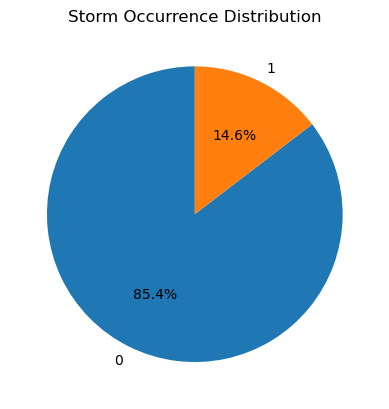

In [22]:
data['storm_happened'].value_counts().plot(kind='pie',autopct='%1.1f%%',startangle=90)
plt.ylabel('')
plt.title('Storm Occurrence Distribution')
plt.show()

This chart shows that storms are not very common in your dataset. Around 85% of the time, no storm happened, and only about 15% of the time a storm occurred.
In simple terms, storms are rare events compared to normal days. This makes sense in real life too — storms don’t happen every day. Even though they are less frequent, they can still be important because earlier we saw that outages increase when a storm happens.

In [23]:
data.groupby('outage_in_next_24_hours')['grid_load_percent'].mean()

outage_in_next_24_hours
0    75.480449
1    96.729179
Name: grid_load_percent, dtype: float64

Comparing average grid load for outage and non-outage cases helps reveal whether higher stress on the power grid is linked with outages. If the outage group has noticeably higher grid load, it suggests that overloaded grids are more vulnerable to failures.

In [24]:
data.groupby('season')['outage_in_next_24_hours'].mean()

season
Autumn     0.497854
Monsoon    0.498141
Summer     0.505792
Winter     0.497908
Name: outage_in_next_24_hours, dtype: float64

This shows in which seasons outages are more likely. If certain seasons have higher outage rates, it indicates that seasonal factors like weather conditions or demand patterns may be influencing power stability.

In [25]:
data.groupby('outage_in_next_24_hours')['electricity_demand_mw'].mean()

outage_in_next_24_hours
0    6661.232676
1    7288.291832
Name: electricity_demand_mw, dtype: float64

If average electricity demand is higher in outage cases, it suggests that peak demand periods may increase the risk of power failures, possibly due to strain on the grid.

In [26]:
data.groupby('storm_happened')['outage_in_next_24_hours'].mean()

storm_happened
0    0.464871
1    0.705479
Name: outage_in_next_24_hours, dtype: float64

This helps understand whether storms significantly affect outages. A higher outage rate when storms occur would indicate that extreme weather is a major contributing factor to grid instability.

In [27]:
data.groupby('outage_in_next_24_hours')[['outages_last_7_days','outages_last_30_days']].mean()

,outages_last_7_days,outages_last_30_days
outage_in_next_24_hours,,
0,1.344391,7.915497
1,1.759640,9.728698


If places that experienced more outages in the past 7 or 30 days also show higher future outage rates, it suggests that historical instability is a strong indicator of upcoming power failures.

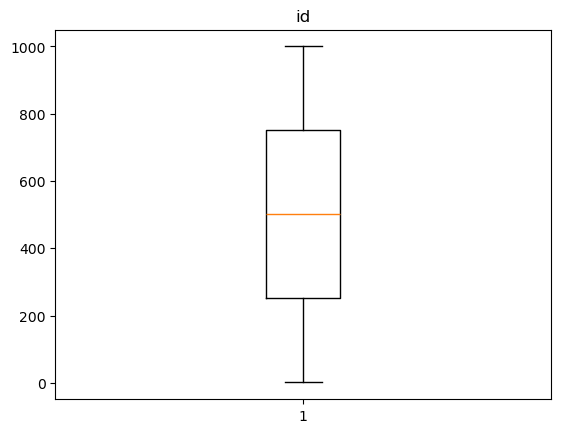

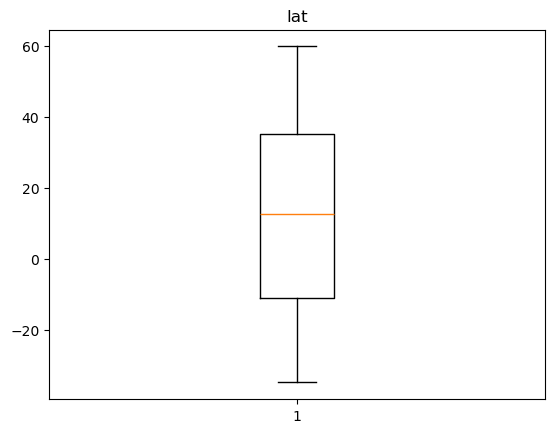

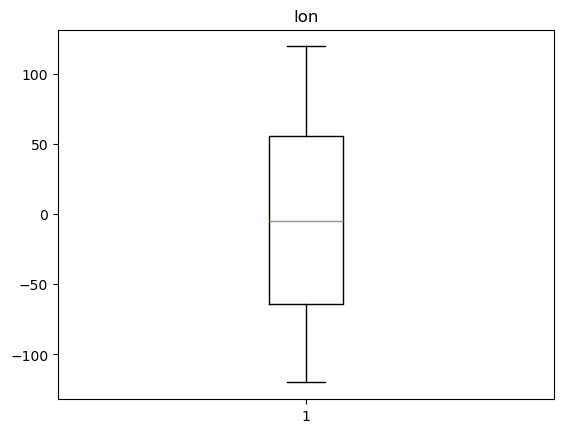

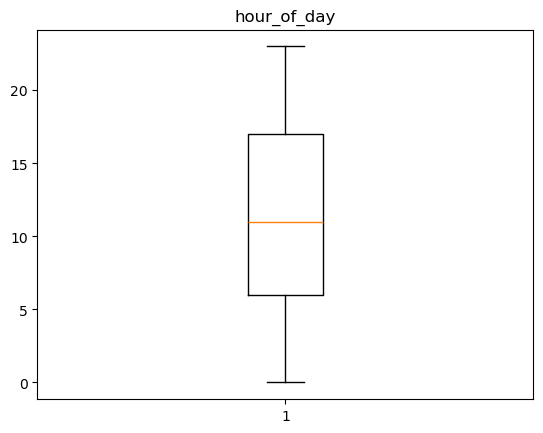

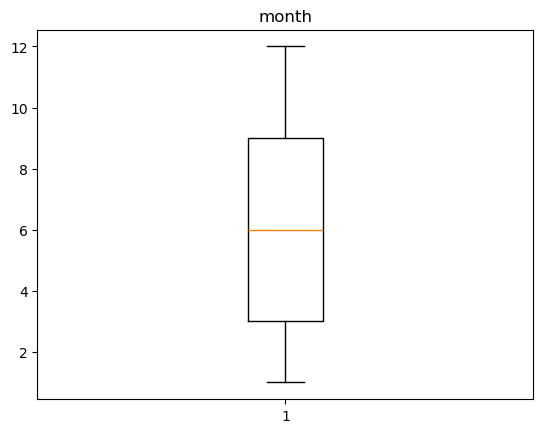

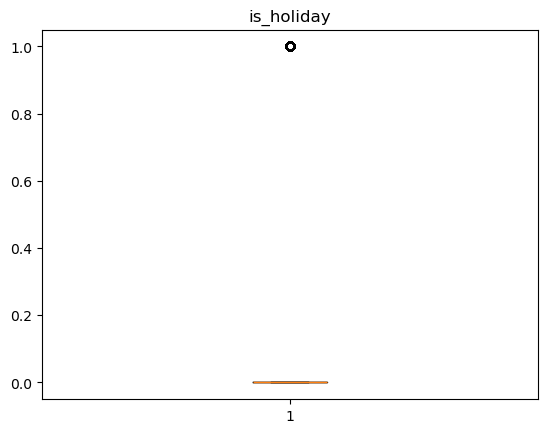

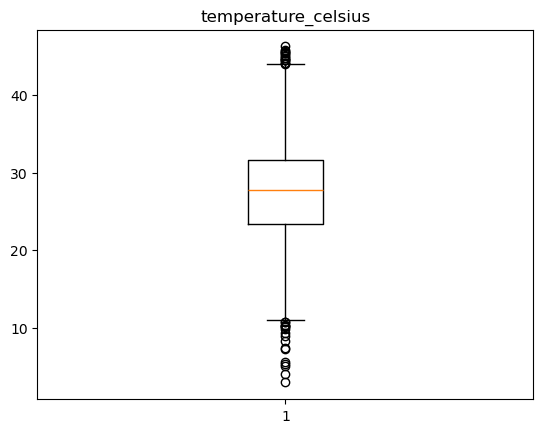

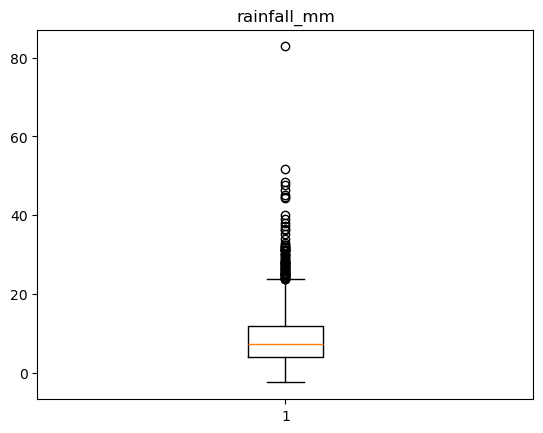

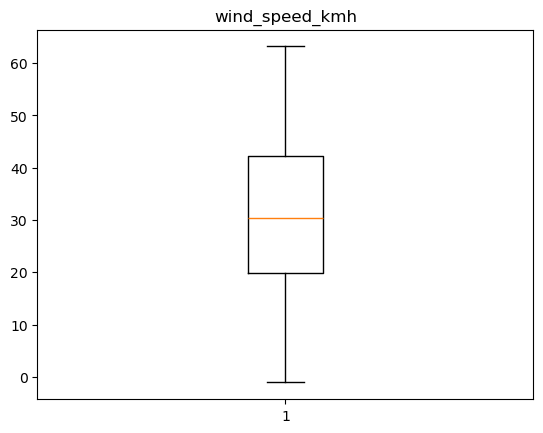

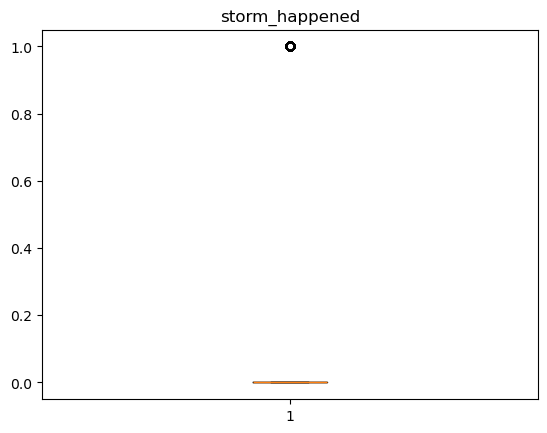

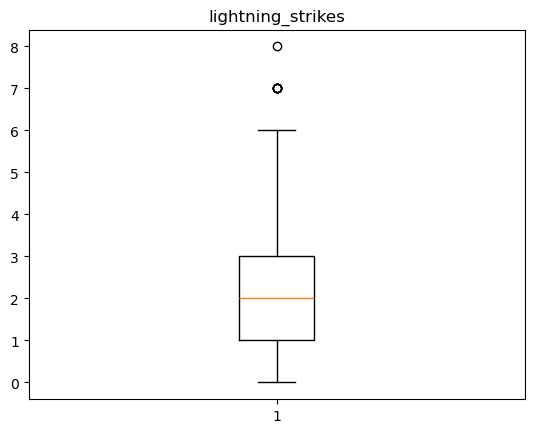

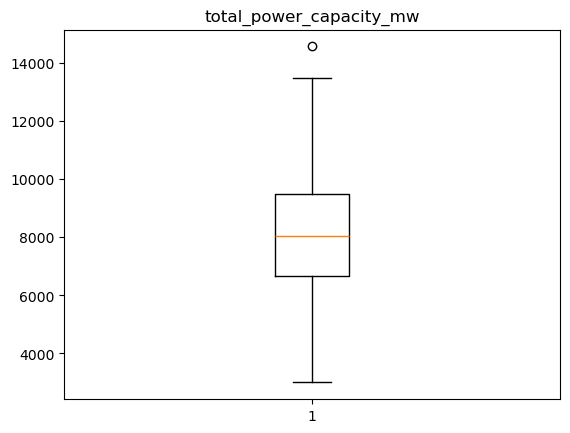

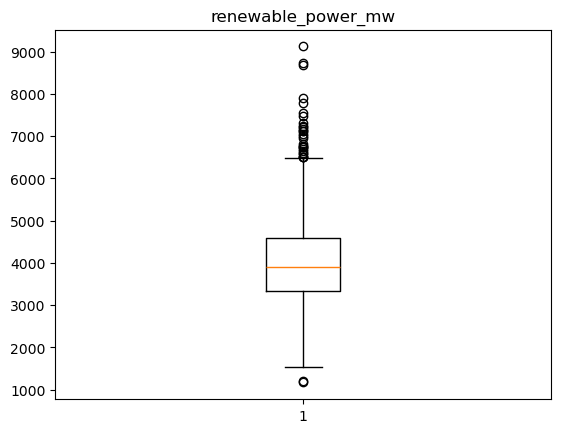

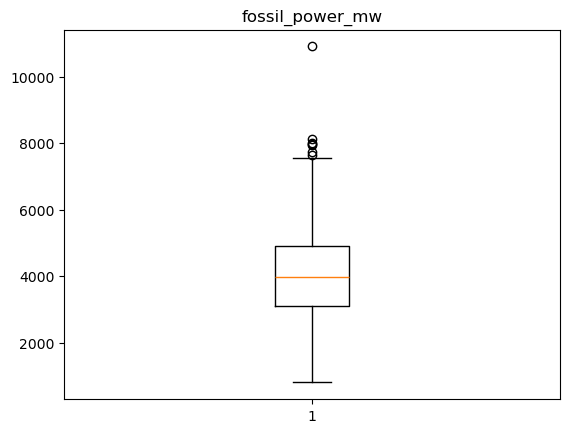

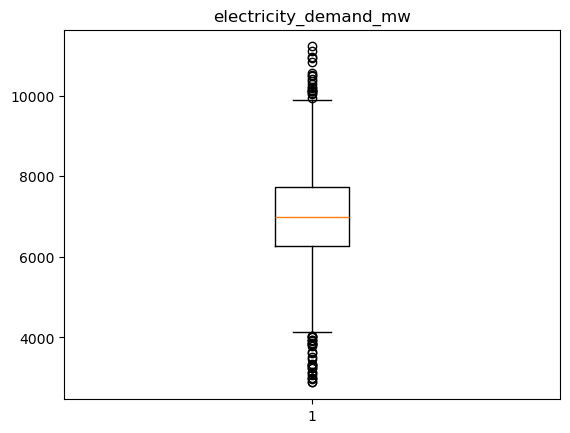

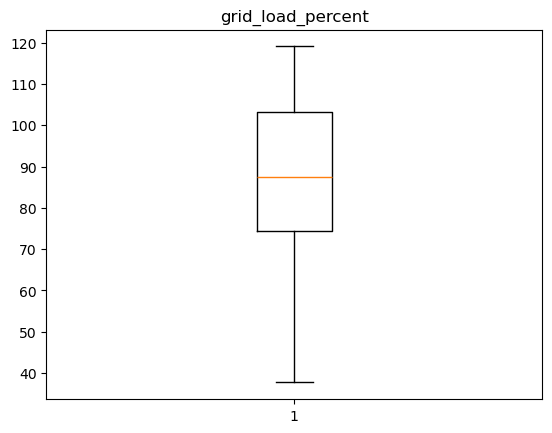

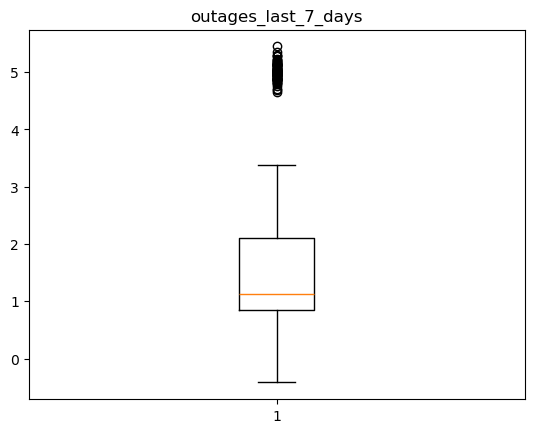

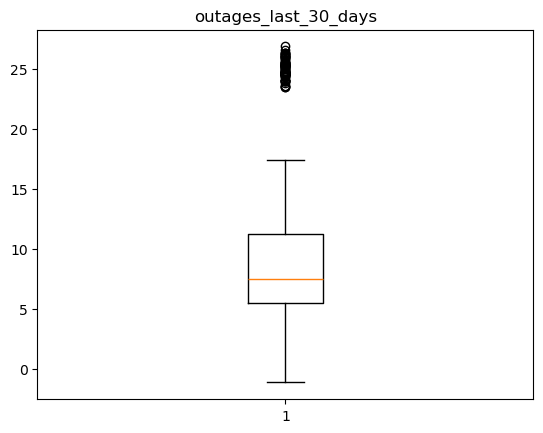

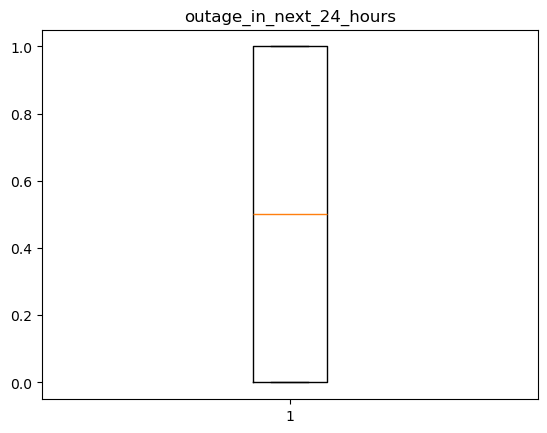

In [28]:
for i in num_cols:
    plt.boxplot(data[i])
    plt.title(i)
    plt.show()

In [29]:
outlier_cols = ['electricity_demand_mw','grid_load_percent','outages_last_30_days']

1.electricity_demand_mw
 
   -Demand data can contain abnormal spikes due to logging or reporting errors, and extreme values can dominate model learning if not controlled.

2.grid_load_percent
  
   -Values close to or above system limits can disproportionately influence the model, even when they result from temporary measurement noise.

3.outages_last_30_days
  
   -Monthly outage counts may include unusually high values that skew patterns, while still needing conservative handling rather than removal.

In [30]:
def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    
    return df

In [31]:
data = remove_outliers(data, outlier_cols)
data.shape

(882, 26)

In [32]:
data['demand_capacity_ratio'] = data['electricity_demand_mw'] / data['total_power_capacity_mw']
data[['demand_capacity_ratio']]

,demand_capacity_ratio
1,0.643976
4,0.611224
5,0.569097
6,0.916577
7,0.854063
...,...
994,0.554266
995,0.999499
997,0.908074
998,0.676182


This feature shows how much electricity demand is being placed relative to the total available power capacity. We created it to capture energy stress conditions, because when demand comes close to or exceeds capacity, the grid becomes unstable and the risk of outages increases. This directly represents energy stability, which is central to the project topic.

In [33]:
data['renewable_share'] = data['renewable_power_mw'] / data['total_power_capacity_mw']
data[['renewable_share']]

,renewable_share
1,0.465359
4,0.528141
5,0.638425
6,0.436181
7,0.415399
...,...
994,0.496487
995,0.531208
997,0.526115
998,0.542456


This feature represents the proportion of renewable energy in the total power supply. We created it to understand how the energy mix affects outage risk, since renewable sources can be intermittent and may impact grid reliability during certain weather or demand conditions. It helps the model learn whether higher or lower renewable dependence influences outages.

In [34]:
data['high_grid_load'] = (data['grid_load_percent'] > 80).astype(int)
data[['high_grid_load']]

,high_grid_load
1,0
4,1
5,1
6,1
7,1
...,...
994,0
995,1
997,1
998,0


This binary feature indicates whether the grid load exceeds 80%, which is considered a high-stress condition for power systems. We created it to explicitly flag critical situations where the grid is under heavy pressure, as high grid load significantly increases the likelihood of failures and outages.

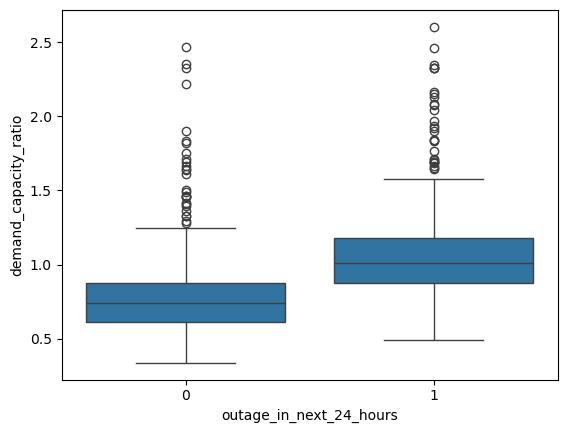

In [35]:
sns.boxplot(x='outage_in_next_24_hours', y='demand_capacity_ratio', data=data)
plt.show()

This boxplot shows that when the demand-capacity ratio is higher, outages are more likely. The outage group clearly has a higher median and overall higher values. In simple terms, when demand gets too close to or exceeds capacity, the system becomes unstable and outages increase.
We didn’t remove the outliers because those high values represent real overload situations. They are not errors — they show extreme stress on the grid, which is actually important for predicting outages.

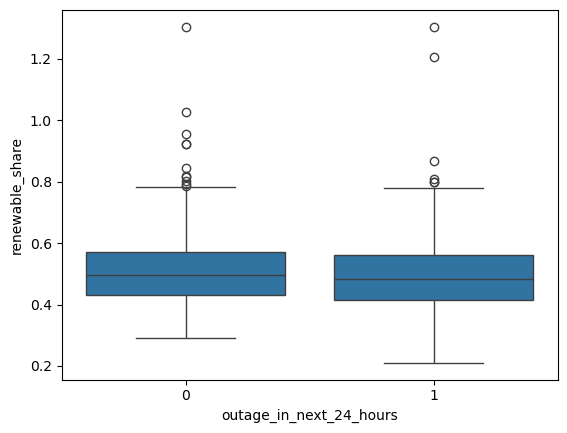

In [36]:
sns.boxplot(x='outage_in_next_24_hours', y='renewable_share', data=data)
plt.show()

The renewable share looks almost the same for both outage and no outage cases. The median and spread are very similar, so it doesn’t seem to strongly affect whether an outage happens.
We didn’t remove the outliers because those higher or lower renewable shares can represent real grid conditions. They are not errors — they show unusual but possible energy mix situations.

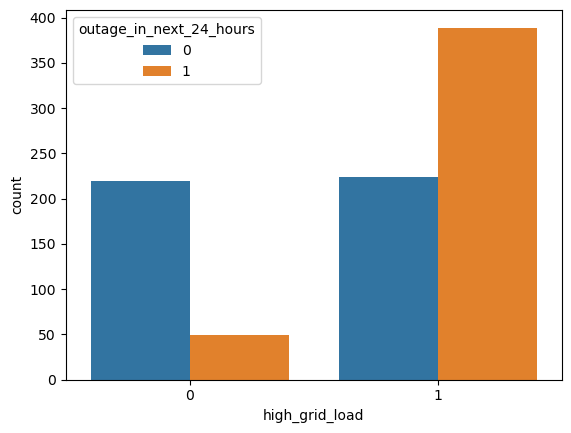

In [37]:
sns.countplot(x='high_grid_load', hue='outage_in_next_24_hours', data=data)
plt.show()

When high grid load is 0, most cases are no outage. But when high grid load is 1, outages increase a lot compared to no outages.
In simple terms, when the grid is under high load, the chances of an outage become much higher. This feature clearly separates outage and no outage casess.

In [38]:
data = data.drop('id', axis=1)
data.head()

,country,state,district,lat,lon,grid_zone,hour_of_day,day_of_week,month,season,...,renewable_power_mw,fossil_power_mw,electricity_demand_mw,grid_load_percent,outages_last_7_days,outages_last_30_days,outage_in_next_24_hours,demand_capacity_ratio,renewable_share,high_grid_load
1,Canada,State_A,District_4,-4.096962,107.221499,South,16,Tue,10,Autumn,...,3508.144615,4153.306123,4854.664324,67.323740,0.394406,5.484861,0,0.643976,0.465359,0
4,USA,State_D,District_7,-17.746673,-56.177172,East,15,Mon,9,Monsoon,...,6395.583774,5923.937790,7401.685866,87.551067,1.997359,11.620220,0,0.611224,0.528141,1
5,France,State_B,District_5,0.239396,117.679753,West,14,Sun,1,Summer,...,6574.519201,4061.870164,5860.572566,87.551067,0.584380,5.237595,0,0.569097,0.638425,1
6,Australia,State_C,District_9,50.684319,-113.815296,North,1,Sat,4,Summer,...,3637.473402,4811.043066,7643.675070,87.551067,3.078148,15.841584,0,0.916577,0.436181,1
7,France,State_C,District_3,41.635884,24.846914,Central,8,Wed,1,Winter,...,3489.681142,5016.635315,7174.807095,83.691509,1.121717,6.983095,1,0.854063,0.415399,1


The id column was removed because it is only an identifier and does not contribute to predicting power outages.

In [39]:
cat_cols

Index(['country', 'state', 'district', 'grid_zone', 'day_of_week', 'season',
       'storm_type'],
      dtype='object')

In [40]:
data.select_dtypes(include='object').columns

Index(['country', 'state', 'district', 'grid_zone', 'day_of_week', 'season',
       'storm_type'],
      dtype='object')

In [42]:
data = data.drop([ 'district', 'state'], axis=1)

In [43]:
data.select_dtypes(include='object').columns

Index(['country', 'grid_zone', 'day_of_week', 'season', 'storm_type'], dtype='object')

In [44]:
x = data.drop('outage_in_next_24_hours', axis=1)
y = data['outage_in_next_24_hours']

In [46]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((705, 25), (177, 25), (705,), (177,))

The dataset was split into training and testing sets to evaluate model performance on unseen data and prevent overfitting.

In [48]:
cat_cols = x_train.select_dtypes(include='object').columns
num_cols = x_train.select_dtypes(include=['int64', 'float64']).columns

In [49]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [50]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [51]:
pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", LogisticRegression())
])

In [53]:
pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['lat', 'lon', 'hour_of_day', 'month', 'is_holiday',
       'temperature_celsius', 'rainfall_mm', 'wind_speed_kmh',
       'storm_happened', 'lightning_strikes', 'total_power_capacity_mw',
       'renewable_power_mw', 'fossil_power_mw', 'electricity_demand_mw',
       'grid_load_percent', 'outages_last_7_days', 'outages_last_30_days',
       'demand_capacity_ratio', 'renewable_share', 'high_grid_load'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['country', 'grid_zone', 'day_of_week', 'season', 'storm_type'], dtype='object'))])),
                ('model', LogisticRegression())])

In [55]:
y_pred = pipeline.predict(x_test)
y_pred

array([1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0,
       0])

In [57]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred)*100)

Accuracy: 79.66101694915254


In [58]:
from sklearn.ensemble import RandomForestClassifier

pipeline_rf = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(n_estimators=100, random_state=42))
])

In [60]:
pipeline_rf.fit(x_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['lat', 'lon', 'hour_of_day', 'month', 'is_holiday',
       'temperature_celsius', 'rainfall_mm', 'wind_speed_kmh',
       'storm_happened', 'lightning_strikes', 'total_power_capacity_mw',
       'renewable_power_mw', 'fossil_power_mw', 'electricity_demand_mw',
       'grid_load_percent', 'outages_last_7_days', 'outages_last_30_days',
       'demand_capacity_ratio', 'renewable_share', 'high_grid_load'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['country', 'grid_zone', 'day_of_week', 'season', 'storm_type'], dtype='object'))])),
                ('model', RandomForestClassifier(random_state=42))])

In [62]:
y_pred_rf = pipeline_rf.predict(x_test)
y_pred_rf

array([1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0])

In [64]:
from sklearn.metrics import accuracy_score

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf)*100)

RF Accuracy: 83.61581920903954


In [65]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature names AFTER preprocessing
feature_names = pipeline_rf.named_steps['preprocessing'].get_feature_names_out()

# Get importance
importances = pipeline_rf.named_steps['model'].feature_importances_

# Create dataframe
feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Show top features
print(feat_imp.head(10))

                         feature  importance
14        num__grid_load_percent    0.163862
17    num__demand_capacity_ratio    0.101514
11       num__renewable_power_mw    0.098795
10  num__total_power_capacity_mw    0.093305
12          num__fossil_power_mw    0.043919
15      num__outages_last_7_days    0.040128
8            num__storm_happened    0.033922
18          num__renewable_share    0.033144
5       num__temperature_celsius    0.032301
13    num__electricity_demand_mw    0.031387


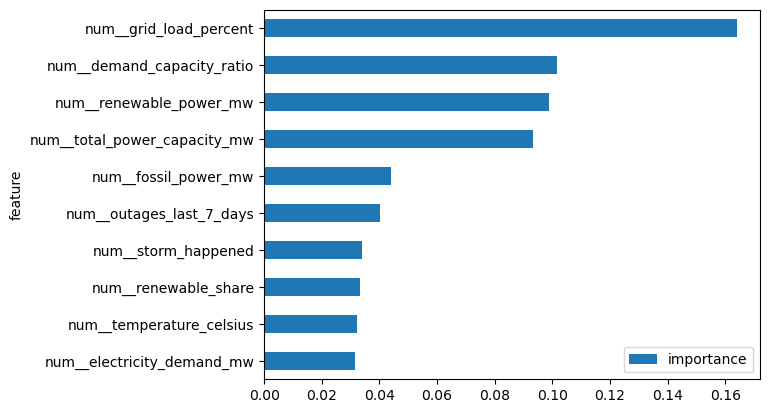

In [66]:
feat_imp.head(10).plot(kind='barh', x='feature', y='importance')
plt.gca().invert_yaxis()
plt.show()

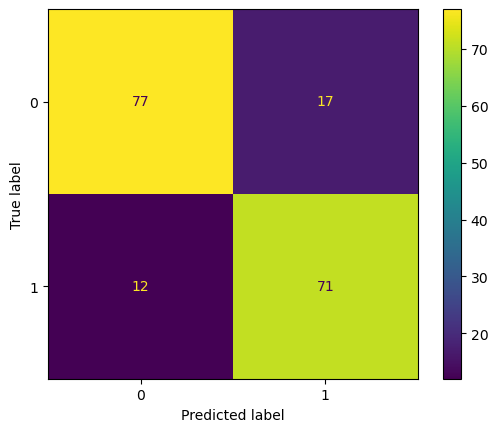

In [67]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [68]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.87      0.82      0.84        94
           1       0.81      0.86      0.83        83

    accuracy                           0.84       177
   macro avg       0.84      0.84      0.84       177
weighted avg       0.84      0.84      0.84       177



In [70]:
from sklearn.metrics import roc_auc_score

y_prob = pipeline_rf.predict_proba(x_test)[:, 1]

roc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.924762881312484


Even though accuracy is moderate, ROC-AUC is high, which shows the model performs well across thresholds and handles class imbalance effectively.

In [71]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [72]:
from xgboost import XGBClassifier
pipeline_xgb = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    ))
])

In [74]:
pipeline_xgb.fit(x_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['lat', 'lon', 'hour_of_day', 'month', 'is_holiday',
       'temperature_celsius', 'rainfall_mm', 'wind_speed_kmh',
       'storm_happened', 'lightning_strikes', 'total_power_capacity_mw',
       'renewable_power_mw', 'fossil_power_mw', 'electricity_demand_mw',
       'grid_load_percent', 'outages...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [76]:
y_pred_xgb = pipeline_xgb.predict(x_test)
y_pred_xgb

array([1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0])

In [80]:
from sklearn.metrics import accuracy_score

print("XGB Accuracy:", accuracy_score(y_test, y_pred_xgb)*100)

XGB Accuracy: 85.31073446327684


In [79]:
from sklearn.metrics import roc_auc_score

y_prob_xgb = pipeline_xgb.predict_proba(x_test)[:, 1]

print("XGB ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

XGB ROC-AUC: 0.9479620610099975


XGBoost performed best due to its boosting nature, which captures complex patterns and reduces bias

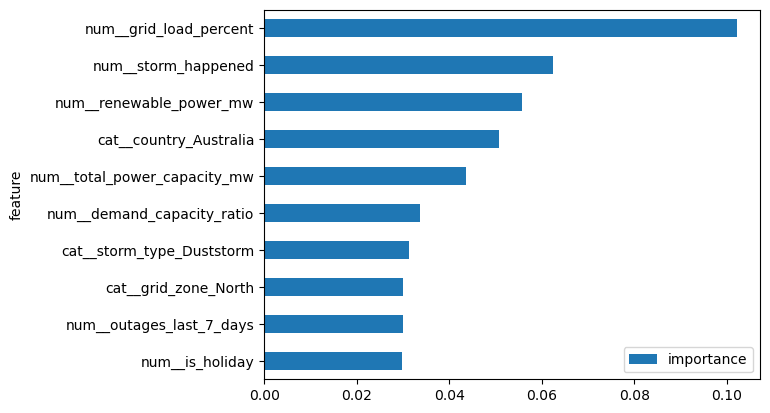

In [81]:
import matplotlib.pyplot as plt

importances = pipeline_xgb.named_steps['model'].feature_importances_
feature_names = pipeline_xgb.named_steps['preprocessing'].get_feature_names_out()

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feat_imp.head(10).plot(kind='barh', x='feature', y='importance')
plt.gca().invert_yaxis()
plt.show()

In [82]:
import joblib

joblib.dump(pipeline_xgb, "power_outage_model.pkl")

['power_outage_model.pkl']

In [83]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [92]:
!streamlit run app.py

^C
